<a href="https://colab.research.google.com/github/matheusd09/mvp-analisedados-boaspraticas/blob/main/mvp_analisedados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Análise de Dados e Boas Práticas

**Nome:** Matheus Fernandes Damasio

**Dataset:** [AI Workforce and Automation Dataset 2015–2025](https://www.kaggle.com/datasets/emirhanakku/ai-workforce-and-automation-dataset-20152025)

**Links raw dos arquivos utilizados:** [Dataset Raw do Git](https://raw.githubusercontent.com/matheusd09/mvp-analisedados-boaspraticas/refs/heads/main/global_ai_workforce_automation_2015_2025.csv)

# Descrição do Problema

A Inteligência Artificial (IA) e a automação estão transformando o mercado de trabalho global de forma acelerada. Países ao redor do mundo respondem a essa transformação de maneiras distintas, a depender do volume de investimentos realizados, da maturidade de suas políticas públicas e do nível de preparo de suas economias para absorver essas mudanças.

O objetivo é entender de acordo com o dataset, como o avanço da IA e da automação de forças de trabalho se relacionam com variáveis como maturidade política, criação e deslocamento de empregos, produtividade, salários e investimento em requalificação profissional.

## Hipóteses do Problema

### Investimento
1. Países que investem mais em IA apresentam maior taxa de automação de força de trabalho?
2. Países que investem mais em IA geram mais empregos?
3. Países com maior nível de preparo e adoção de IA investem proporcionalmente mais na requalificação profissional?

### Produtividade
4. A produtividade de um país está associada ao nível de preparo e adoção de IA, à maturidade das políticas de IA e/ou ao volume de investimento em IA?

### Empregabilidade
5. Países com políticas de IA mais maduras investem mais na requalificação de seus trabalhadores?
6. O avanço da automação da força de trabalho está associado ao aumento da substituição de empregos pela IA?
7. A substituição de empregos pela IA é compensada pela criação de novos postos de trabalho ao longo do período analisado?

## Tipo de Problema

Este trabalho não se enquadra diretamente como um problema de aprendizado supervisionado ou não supervisionado, pois não há aplicação de modelos preditivos ou algoritmos de agrupamento. Trata-se de uma análise exploratória de dados com pré-processamento, orientada à investigação de correlações, tendências temporais e comparações entre países sobre o impacto da IA no mercado de trabalho global.
O foco é compreender como indicadores de investimento, automação, empregabilidade e produtividade se relacionam entre si e evoluem ao longo do período 2015–2025. Caso o trabalho avance para uma etapa de modelagem, a ausência de uma variável-alvo definida sugere que técnicas de aprendizado não supervisionado (como clustering de países por perfil) seriam mais adequadas.

## Seleção dos Dados

A seleção de dados se dá pela analisa do dataset **AI Workforce and Automation Dataset 2015–2025**, que reúne
indicadores econômicos e de mercado de trabalho de 20 países ao longo de 11 anos (2015–2025).

O dataset foi selecionado por englobar múltiplas dimensões do impacto da IA no mercado de
trabalho, como investimento, automação, empregabilidade e produtividade em um recorte temporal
relevante e com representatividade geográfica e de desenvolvimento econômico diversificada.

Não foram aplicados filtros de seleção: o dataset é utilizado em sua totalidade, considerando
todos os países e anos disponíveis.

## Atributos do Dataset

O dataset possui 220 amostras e 12 atributos:

| Atributo | Tipo | Descrição | Faixa de Valores |
|---|---|---|---|
| `Year` | Inteiro | Ano de referência do registro | 2015–2025 |
| `Country` | Categórico | País de referência | 20 países |
| `AI_Investment_BillionUSD` | Numérico | Investimento Anual em IA (em bilhões de dólares) | 5–200 |
| `Automation_Rate_Percent` | Numérico | Percentual da força de trabalho automatizada | 10–95% |
| `Employment_Rate_Percent` | Numérico | Percentual da população total empregada | 50–80% |
| `Average_Salary_USD` | Numérico | Salário médio anual (em dólares) | 25.000–90.000 |
| `Productivity_Index` | Numérico | Índice de produtividade | 0–100 |
| `Reskilling_Investment_MillionUSD` | Numérico | Investimento em requalificação profissional (em milhões de dólares) | 100–5.000 |
| `AI_Policy_Index` | Numérico | Índice de maturidade das políticas públicas de IA | 0–1 |
| `Job_Displacement_Million` | Numérico | Estimativa de empregos substituídos pela automação (em milhões) | 0–3 |
| `Job_Creation_Million` | Numérico | Novos empregos criados pela IA (em milhões) | 0–4 |
| `AI_Readiness_Score` | Numérico | Índice composto de prontidão e adoção de IA | 0–100 |


Observação: Existe divergência entre faixa documentada e a observada em alguns atributos.

## Importação de Bibliotecas e Carga de Dados

Esta seção centraliza todas as importações de bibliotecas utilizadas ao longo do notebook. Em seguida, o dataset
é carregado diretamente do repositório GitHub e inspecionado.

In [ ]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Configurações globais de visualização
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

In [ ]:
# URL do dataset no repositório GitHub
URL = "https://raw.githubusercontent.com/matheusd09/mvp-analisedados-boaspraticas/refs/heads/main/global_ai_workforce_automation_2015_2025.csv"

# Carregamento do dataset
df = pd.read_csv(URL)

### Inspeção Inicial

In [ ]:
# Primeiras linhas do dataset
df.head()

,Year,Country,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
0,2015,United States,52.46,10.75,65.50,38392.64,65.78,709.03,0.64,0.19,0.14,47.87
1,2016,United States,60.64,11.64,65.25,39371.74,67.02,815.38,0.75,0.16,0.85,43.85
2,2017,United States,66.11,12.46,64.93,40772.29,68.51,921.74,0.51,0.17,1.23,37.13
3,2018,United States,72.45,13.35,64.84,43974.92,71.09,1028.09,0.69,0.27,0.76,42.28
4,2019,United States,79.11,14.65,64.55,43745.39,69.89,1134.45,0.57,0.25,0.85,43.95


A inspeção das primeiras linhas revela que o dataset está bem estruturado. Alguns pontos que chamam a atenção:

- Os valores de `AI_Investment_BillionUSD` já nas primeiras linhas variam bastante entre os registros, sugerindo alta dispersão.

- O atributo `AI_Policy_Index` opera em escala 0–1, enquanto os demais índices (`Productivity_Index`, `AI_Readiness_Score`) operam em escalas distintas, o que será relevante no pré-processamento.

- Não há valores obviamente incorretos ou fora do esperado nas primeiras linhas, como negativos ou zeros em atributos que não deveriam tê-los.

- A combinação de `Year` e `Country` funciona como identificador único de cada registro, cada linha representa um país em um determinado ano.

# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset **AI Workforce and Automation**, o objetivo é compreender a estrutura, as informações disponíveis, as características de cada atributo e a qualidada, que serão utilizados no trabalho.

A análise é conduzida em três frentes: visão geral
do dataset, estatísticas descritivas e visualizações.

## Visão Geral do Dataset

In [ ]:
# Dimensões do dataset: número de linhas e colunas
print(f"Instâncias (linhas): {df.shape[0]}")
print(f"Atributos (colunas): {df.shape[1]}")

Instâncias (linhas): 220
Atributos (colunas): 12


In [ ]:
# Tipos de dados e contagem de valores não nulos por coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year                              220 non-null    int64  
 1   Country                           220 non-null    object 
 2   AI_Investment_BillionUSD          220 non-null    float64
 3   Automation_Rate_Percent           220 non-null    float64
 4   Employment_Rate_Percent           220 non-null    float64
 5   Average_Salary_USD                220 non-null    float64
 6   Productivity_Index                220 non-null    float64
 7   Reskilling_Investment_MillionUSD  220 non-null    float64
 8   AI_Policy_Index                   220 non-null    float64
 9   Job_Displacement_Million          220 non-null    float64
 10  Job_Creation_Million              220 non-null    float64
 11  AI_Readiness_Score                220 non-null    float64
dtypes: float

In [ ]:
df.columns

Index(['Year', 'Country', 'AI_Investment_BillionUSD',
       'Automation_Rate_Percent', 'Employment_Rate_Percent',
       'Average_Salary_USD', 'Productivity_Index',
       'Reskilling_Investment_MillionUSD', 'AI_Policy_Index',
       'Job_Displacement_Million', 'Job_Creation_Million',
       'AI_Readiness_Score'],
      dtype='object')

In [ ]:
df.dtypes

,0
Year,int64
Country,object
AI_Investment_BillionUSD,float64
Automation_Rate_Percent,float64
Employment_Rate_Percent,float64
Average_Salary_USD,float64
Productivity_Index,float64
Reskilling_Investment_MillionUSD,float64
AI_Policy_Index,float64
Job_Displacement_Million,float64


O dataset é composto por **220 instâncias e 12 atributos**.

Cada instância representa
um país em um determinado ano.

Os atributos são **majoritariamente** numéricos do tipo
`float64`, com exceção de **Year** que é `inteiro` e **Country** que é `categórico`.

In [ ]:
# Verificação de valores nulos por coluna
df.isnull().sum()

,0
Year,0
Country,0
AI_Investment_BillionUSD,0
Automation_Rate_Percent,0
Employment_Rate_Percent,0
Average_Salary_USD,0
Productivity_Index,0
Reskilling_Investment_MillionUSD,0
AI_Policy_Index,0
Job_Displacement_Million,0


In [ ]:
# Verificação de registros duplicados
print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


O dataset não apresenta valores nulos nem registros duplicados. Isso elimina a necessidade
de etapas de imputação/tratamento de missing values ou remoção de duplicatas no pré-processamento.

## Estatísticas Descritivas

In [ ]:
# Resumo estatístico dos atributos numéricos
df.describe().round(2)

,Year,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
count,220.00,220.00,220.00,220.00,220.00,220.00,220.00,220.00,220.00,220.00,220.00
mean,2020.00,82.36,27.35,68.82,62074.48,60.61,939.96,0.60,0.37,1.25,43.92
std,3.17,42.52,8.86,5.83,19472.12,11.09,522.84,0.16,0.22,1.02,5.58
min,2015.00,5.40,10.19,57.12,26787.83,40.40,141.24,0.18,0.02,0.03,32.91
25%,2017.00,47.64,20.34,63.96,45251.79,51.83,520.21,0.48,0.19,0.43,39.84
50%,2020.00,81.38,27.08,68.80,60828.00,59.00,881.58,0.62,0.35,0.94,42.88
75%,2023.00,114.48,33.81,73.75,75539.00,69.68,1278.68,0.72,0.52,1.74,48.07
max,2025.00,177.29,48.41,79.95,117335.31,87.26,2371.55,1.00,1.01,4.95,59.10


In [ ]:
# Mediana e moda dos atributos numéricos
numeric_cols = df.select_dtypes(include='number').columns

resumo = pd.DataFrame({
    'Média':    df[numeric_cols].mean(),
    'Mediana':  df[numeric_cols].median(),
    'Moda':     df[numeric_cols].mode().iloc[0],
    'DesvPadrão': df[numeric_cols].std(),
    'Mínimo':   df[numeric_cols].min(),
    'Máximo':   df[numeric_cols].max(),
    'Nulos':    df[numeric_cols].isnull().sum()
}).round(2)

resumo

,Média,Mediana,Moda,DesvPadrão,Mínimo,Máximo,Nulos
Year,2020.00,2020.00,2015.00,3.17,2015.00,2025.00,0
AI_Investment_BillionUSD,82.36,81.38,5.40,42.52,5.40,177.29,0
Automation_Rate_Percent,27.35,27.08,19.23,8.86,10.19,48.41,0
Employment_Rate_Percent,68.82,68.80,62.89,5.83,57.12,79.95,0
Average_Salary_USD,62074.48,60828.00,26787.83,19472.12,26787.83,117335.31,0
Productivity_Index,60.61,59.00,51.14,11.09,40.40,87.26,0
Reskilling_Investment_MillionUSD,939.96,881.58,141.24,522.84,141.24,2371.55,0
AI_Policy_Index,0.60,0.62,0.72,0.16,0.18,1.00,0
Job_Displacement_Million,0.37,0.35,0.10,0.22,0.02,1.01,0
Job_Creation_Million,1.25,0.94,0.31,1.02,0.03,4.95,0


Alguns pontos de atenção identificados nas estatísticas descritivas:
- `AI_Investment_BillionUSD`: média de \$82,36 bilhões com desvio padrão de \$42,52 bilhões, indicando grande dispersão entre os países, o que é esperado dado o intervalo de \$5,40 a \$177,29 bilhões.

- `Average_Salary_USD`: média de \$62.074 com desvio padrão de \$19.472, refletindo a diversidade econômica dos 20 países analisados. O salário máximo de \$117.335 sugere a presença de países com economias significativamente mais desenvolvidas.

- `AI_Policy_Index`: único atributo em escala 0–1, enquanto os demais índices operam em escalas distintas. Esse aspecto será considerado no pré-processamento.

- `Job_Creation_Million`: média de 1,25 milhão de empregos criados, superior à média de deslocamento de 0,37 milhão. Uma primeira indicação de que a criação supera o deslocamento no agregado, hipótese que será investigada com mais profundidade, levando em conta a escala de cada um.

- `Automation_Rate_Percent`: média de 27,35%, com máximo de 48,41%, indicando que nenhum país atingiu níveis extremos de automação no período analisado.

## Visualizações

### Distribuição dos Atributos Numéricos

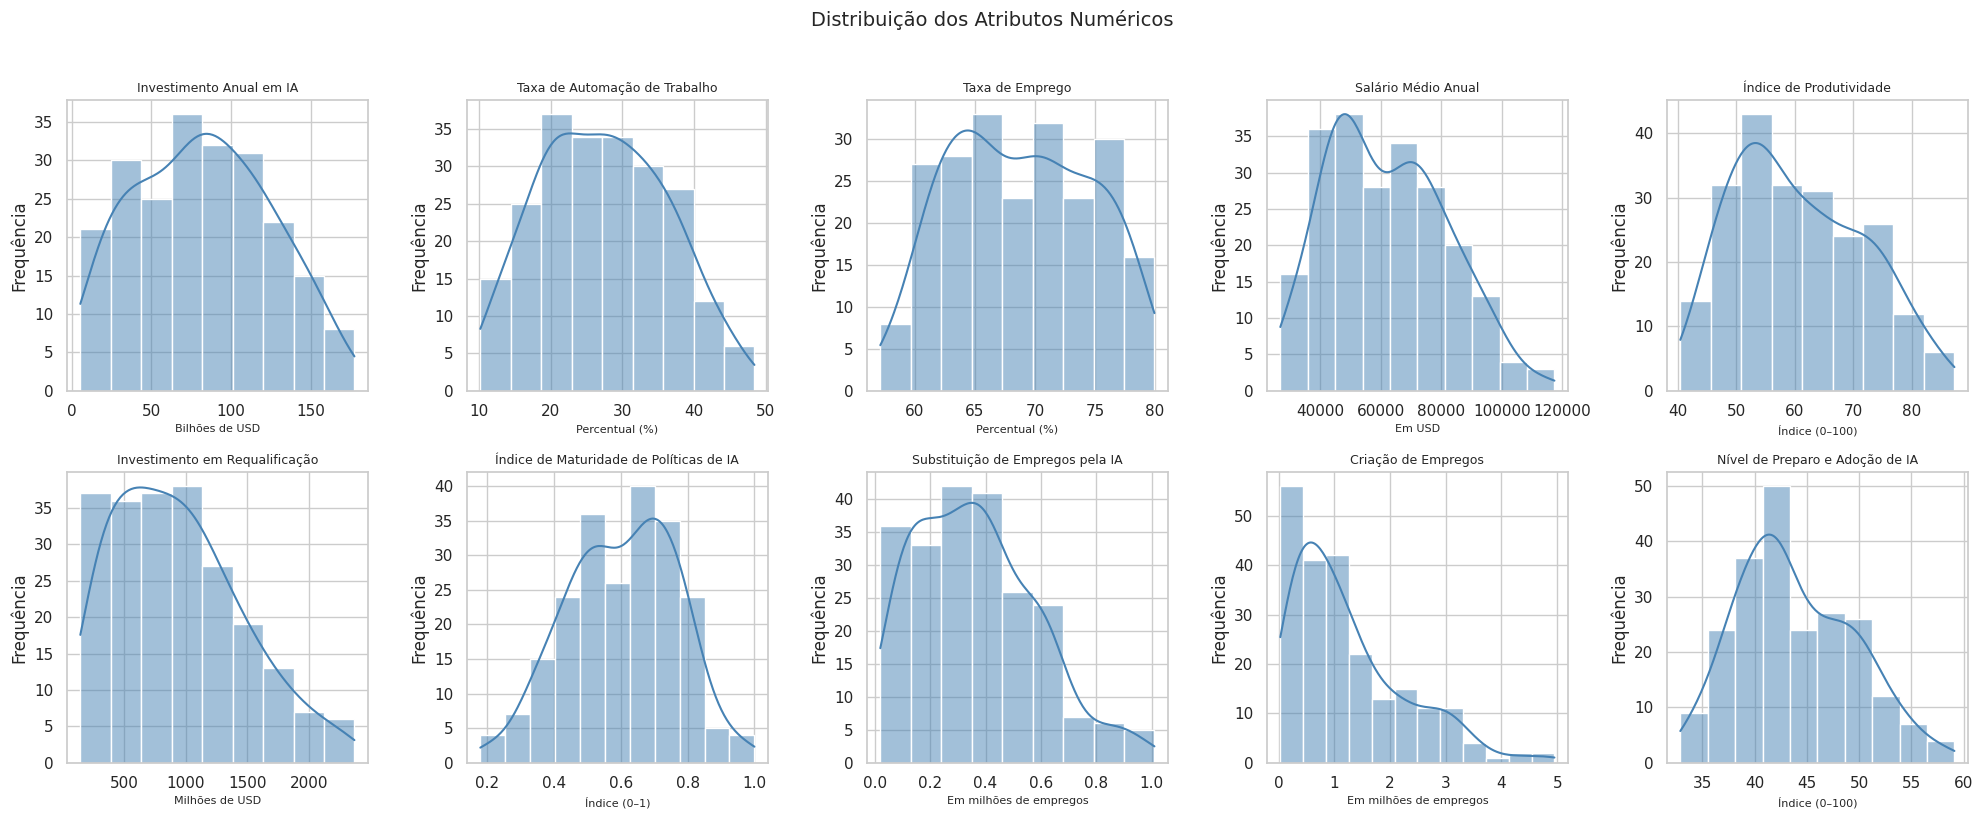

In [ ]:
# Atributos numéricos excluindo Year (variável de controle temporal)
numeric_cols = df.select_dtypes(include='number').drop(columns=['Year']).columns

# Mapeamento de nomes técnicos para títulos legíveis em português
labels = {
    'AI_Investment_BillionUSD':         'Investimento Anual em IA',
    'Automation_Rate_Percent':          'Taxa de Automação de Trabalho',
    'Employment_Rate_Percent':          'Taxa de Emprego',
    'Average_Salary_USD':               'Salário Médio Anual',
    'Productivity_Index':               'Índice de Produtividade',
    'Reskilling_Investment_MillionUSD': 'Investimento em Requalificação',
    'AI_Policy_Index':                  'Índice de Maturidade de Políticas de IA',
    'Job_Displacement_Million':         'Substituição de Empregos pela IA',
    'Job_Creation_Million':             'Criação de Empregos',
    'AI_Readiness_Score':               'Nível de Preparo e Adoção de IA',
}

# Mapeamento das unidades para o eixo X de cada atributo
xlabels = {
    'AI_Investment_BillionUSD':         'Bilhões de USD',
    'Automation_Rate_Percent':          'Percentual (%)',
    'Employment_Rate_Percent':          'Percentual (%)',
    'Average_Salary_USD':               'Em USD',
    'Productivity_Index':               'Índice (0–100)',
    'Reskilling_Investment_MillionUSD': 'Milhões de USD',
    'AI_Policy_Index':                  'Índice (0–1)',
    'Job_Displacement_Million':         'Em milhões de empregos',
    'Job_Creation_Million':             'Em milhões de empregos',
    'AI_Readiness_Score':               'Índice (0–100)',
}

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(labels[col], fontsize=9)
    axes[i].set_xlabel(xlabels[col], fontsize=8)
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição dos Atributos Numéricos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

A análise dos histogramas revela o seguinte sobre a distribuição de cada atributo:

- **Investimento Anual em IA** (`AI_Investment_BillionUSD`): Unimodal com leve assimetria positiva. Pico entre \$50–100 bilhões, indicando que a maioria dos países investe em faixas intermediárias, sem concentração em extremos.

- **Taxa de Automação de Trabalho** (`Automation_Rate_Percent`): Assimetria positiva, pico entre 20–35\% com cauda se estendendo até quase 50%. A maioria dos registros está abaixo de 35%, indicando que automação elevada ainda é exceção entre os países analisados.

- **Taxa de Emprego** (`Employment_Rate_Percent`): Distribuição ampla e com valores espalhados entre 60–80%, sem forte concentração em uma única faixa.

- **Salário Médio Anual** (`Average_Salary_USD`): Assimetria positiva, concentração forte entre \$40.000–60.000, com cauda longa à direita até \$120.000.

- **Índice de Produtividade** (`Productivity_Index`): Assimetria positiva, com pico entre 47–65 e cauda se estendendo até 85.

- **Investimento em Requalificação** (`Reskilling_Investment_MillionUSD`): Assimetria positiva, com concentração principal entre \$<500–1.200 milhões, e cauda se estendendo até próximo de \$2.500 milhões(2.5 bilhoes).

- **Índice de Maturidade de Políticas de IA** (`AI_Policy_Index`): Distribuição com indício de bimodalidade com dois picos visíveis em torno de 0,4-0,5 e 0,7–0,8.

- **Substituição de Empregos pela IA** (`Job_Displacement_Million`): Assimetria positiva, com concentração entre 0,1–0,5 milhões e cauda à direita chegando a 1,0 milhão.

- **Criação de Empregos** (`Job_Creation_Million`): Forte assimetria positiva, com concentração acentuada no intervalo 0-1 milhão e cauda longa até cerca de 5 milhões.

- **Nível de Preparo e Adoção de IA** (`AI_Readiness_Score`): Distribuição com leve assimetria positiva, concentrada entre 38–50%.

### Evolução Temporal dos Principais Indicadores

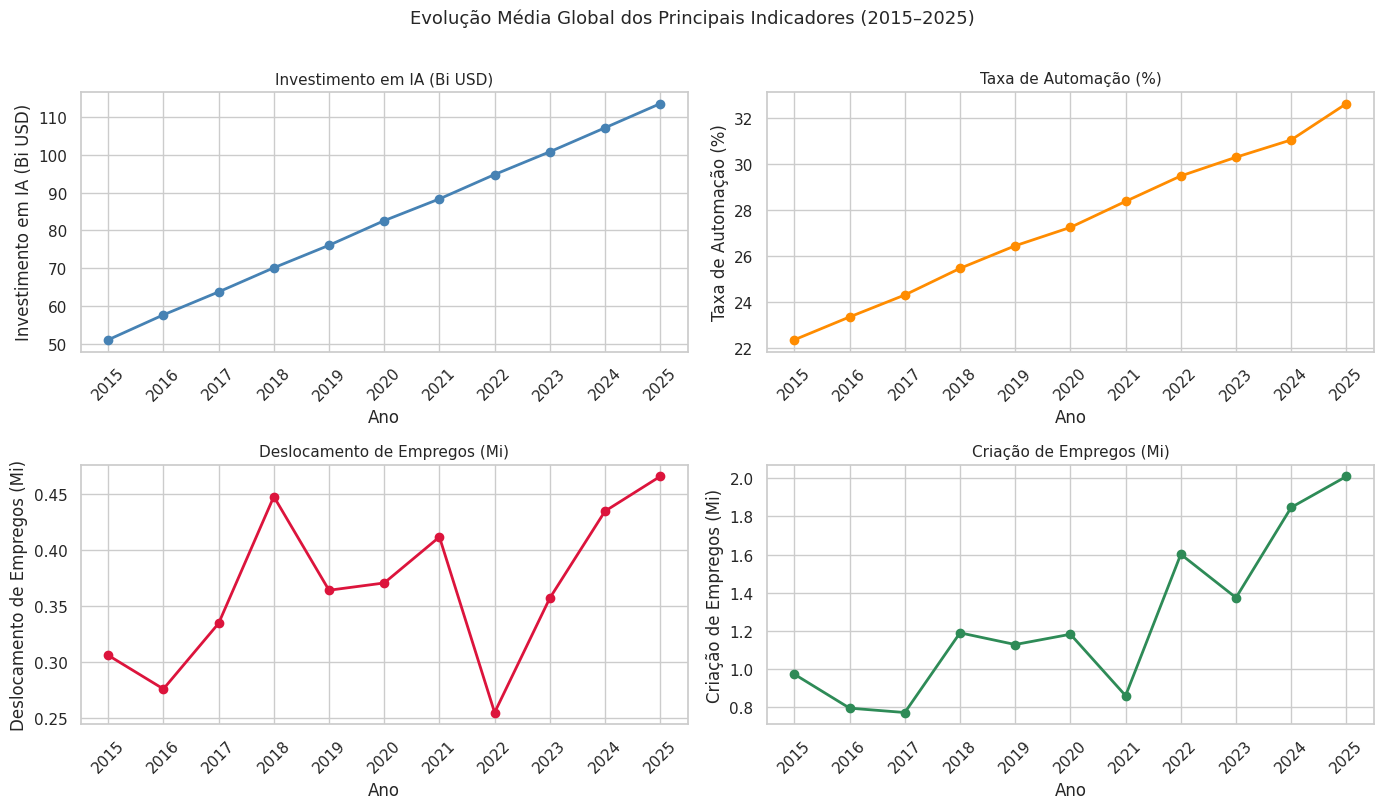

In [ ]:
# Média global por ano dos principais indicadores
evolucao = df.groupby('Year')[
    ['AI_Investment_BillionUSD', 'Automation_Rate_Percent',
     'Job_Displacement_Million', 'Job_Creation_Million']
].mean().reset_index()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))

indicadores = {
    'AI_Investment_BillionUSD':    ('Investimento em IA (Bi USD)',       'steelblue'),
    'Automation_Rate_Percent':     ('Taxa de Automação (%)',              'darkorange'),
    'Job_Displacement_Million':    ('Deslocamento de Empregos (Mi)',      'crimson'),
    'Job_Creation_Million':        ('Criação de Empregos (Mi)',           'seagreen'),
}

for ax, (col, (label, color)) in zip(axes.flatten(), indicadores.items()):
    ax.plot(evolucao['Year'], evolucao[col], marker='o', color=color, linewidth=2)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Ano')
    ax.set_ylabel(label)
    ax.set_xticks(evolucao['Year'])
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Evolução Média Global dos Principais Indicadores (2015–2025)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Evolução Temporal dos Indicadores

A análise temporal permite observar como cada indicador evoluiu em média globalmente
ao longo dos 11 anos, revelando tendências de crescimento, estabilidade ou declínio
associadas ao avanço da IA.

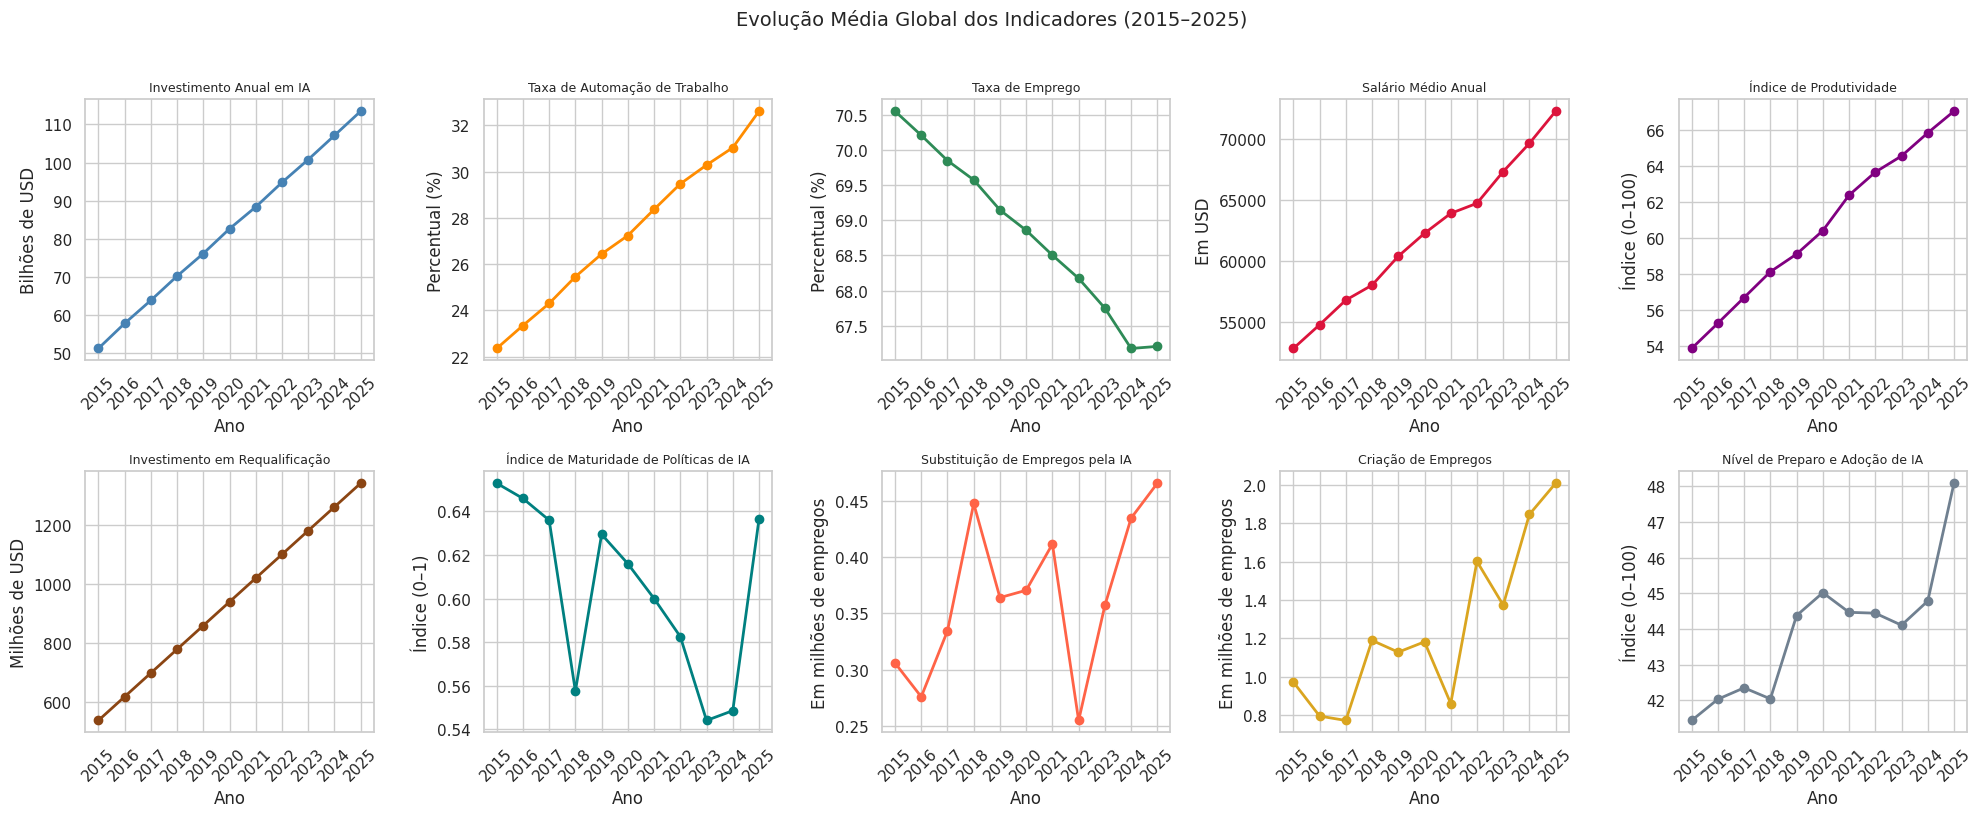

In [ ]:
# Média global por ano de todos os atributos numéricos
evolucao = df.groupby('Year')[numeric_cols].mean().reset_index()

# Cores por atributo para distinguir os subplots
cores = [
    'steelblue', 'darkorange', 'seagreen', 'crimson', 'purple',
    'saddlebrown', 'teal', 'tomato', 'goldenrod', 'slategray'
]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()

for i, (col, cor) in enumerate(zip(numeric_cols, cores)):
    axes[i].plot(evolucao['Year'], evolucao[col], marker='o', color=cor, linewidth=2)
    axes[i].set_title(labels[col], fontsize=9)
    axes[i].set_xlabel('Ano')
    axes[i].set_ylabel(xlabels[col])
    axes[i].set_xticks(evolucao['Year'])
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Evolução Média Global dos Indicadores (2015–2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

A evolução temporal revela tendências distintas entre os indicadores:

- **Crescimento contínuo:** `Investimento em IA` cresceu de \$51 bilhões em 2015 para $113 bilhões em 2025, aumento de próximo a 122%. `Taxa de Automação` subiu de 22% para 33%. `Salário Médio`, `Índice de Produtividade` e `Investimento em Requalificação` também apresentam crescimento contínuo ao longo de todo o período.

- **Declínio gradual:** `Taxa de Emprego` caiu de 70,6% em 2015 para 67,2% em 2025, mantendo a trajetória descendente ao longo do período.

- **Oscilação com tendência de crescimento:** `Criação de Empregos` oscila ao longo do período, mas apresenta tendência de crescimento a partir de 2021, com valor de 2,01 milhões em 2025, o maior valor do período. `Substituição de Empregos pela IA` também oscila no período, mas apresenta elevação nos anos finais da série, alcançando em 2025 o maior valor observado.

- **Relativa estabilidade:** `Índice de Maturidade de Políticas de IA` oscila ao longo do período dentro de uma faixa estreita entre 0,54 e 0,65, sem tendência linear clara. `Nível de Preparo e Adoção de IA` mantém-se relativamente estável entre 41–45 de 2015 a 2024, apresentando elevação para 48 em 2025.

### Investimento em IA por País

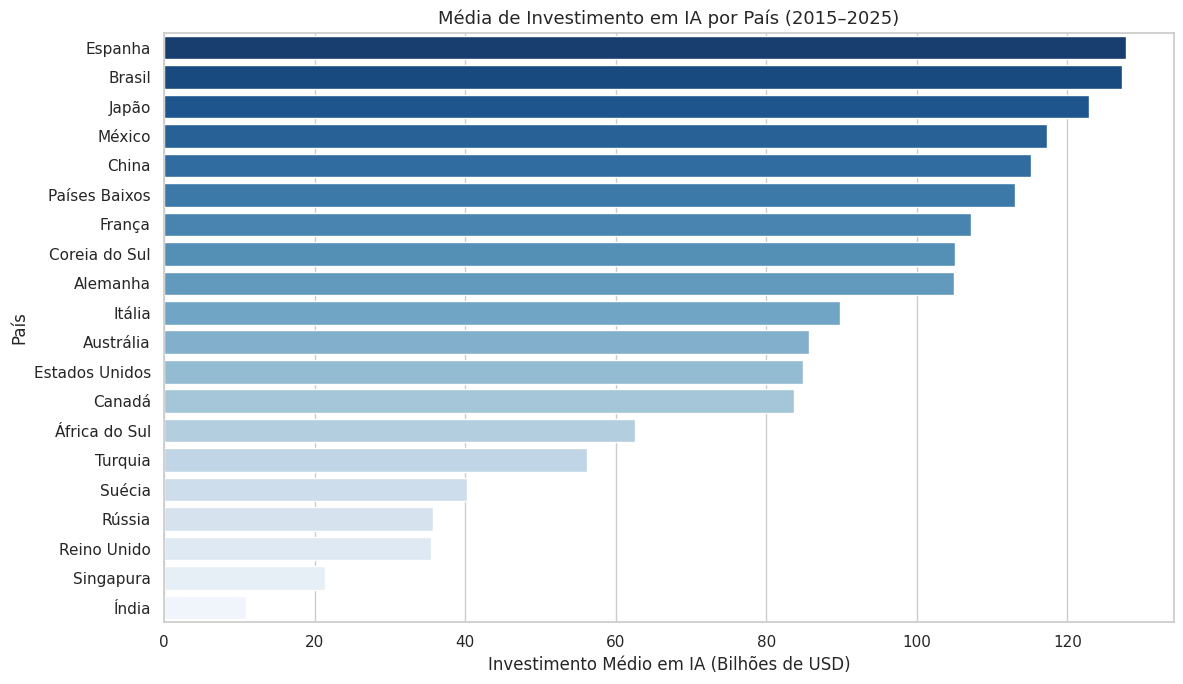

In [ ]:
# Dicionário de tradução dos nomes dos países
paises_pt = {
    'United States':  'Estados Unidos',
    'China':          'China',
    'India':          'Índia',
    'Germany':        'Alemanha',
    'Japan':          'Japão',
    'South Korea':    'Coreia do Sul',
    'France':         'França',
    'United Kingdom': 'Reino Unido',
    'Canada':         'Canadá',
    'Australia':      'Austrália',
    'Brazil':         'Brasil',
    'Russia':         'Rússia',
    'Netherlands':    'Países Baixos',
    'Sweden':         'Suécia',
    'Turkey':         'Turquia',
    'Singapore':      'Singapura',
    'Spain':          'Espanha',
    'Italy':          'Itália',
    'South Africa':   'África do Sul',
    'Mexico':         'México',
}

# Média de investimento em IA por país, ordenada de forma decrescente
invest_pais = (
    df.groupby('Country')['AI_Investment_BillionUSD']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Aplicar tradução
invest_pais['Country'] = invest_pais['Country'].map(paises_pt)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=invest_pais,
    x='AI_Investment_BillionUSD',
    y='Country',
    hue='Country',
    palette='Blues_r',
    legend=False
)
plt.title('Média de Investimento em IA por País (2015–2025)', fontsize=13)
plt.xlabel('Investimento Médio em IA (Bilhões de USD)')
plt.ylabel('País')
plt.tight_layout()
plt.show()

O ranking de investimento médio em IA traz um resultado contraintuitivo: **Espanha e Brasil lideram**, superando potências tecnológicas como Estados Unidos, China e Alemanha.
No extremo oposto, **Índia, Singapura e Reino Unido** registram os menores investimentos médios do período.

**Esse padrão merece atenção:** países tradicionalmente associados à liderança tecnológica global não encabeçam o ranking de investimento. Isso pode refletir uma limitação do dataset, onde os valores podem representar investimento total sem ajuste pelo tamanho da economia, ou pode indicar esforços proporcionalmente maiores de países em aceleração de adoção de IA. Esse resultado será retomado na análise das hipóteses de investimento.

### Identificação de Outliers

A identificação de outliers é realizada visualmente por meio de boxplots e confirmada pelo critério IQR (1,5 * intervalo interquartil). Valores além desse limite são considerados discrepantes e merecem atenção no pré-processamento.

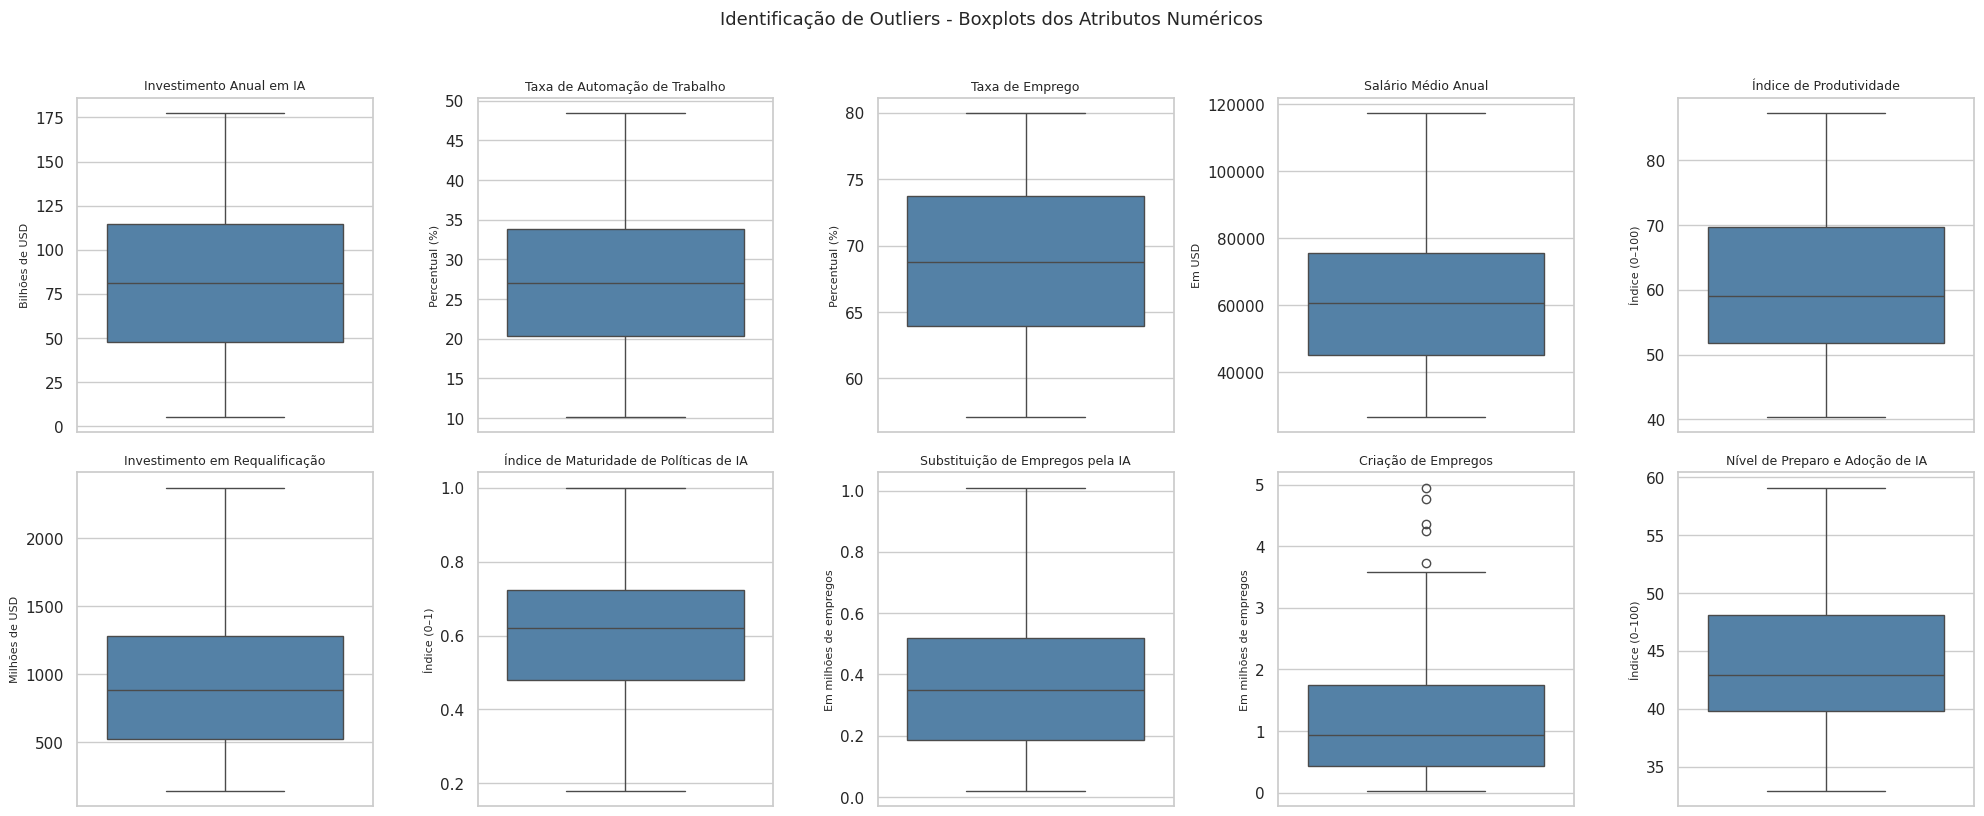

In [ ]:
# Boxplot dos atributos numéricos para identificação visual de outliers
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(labels[col], fontsize=9)
    axes[i].set_ylabel(xlabels[col], fontsize=8)

plt.suptitle('Identificação de Outliers - Boxplots dos Atributos Numéricos',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Confirmação dos outliers pelo critério IQR
print("Outliers identificados pelo critério IQR (1,5 × IQR):\n")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{labels[col]}: {len(outliers)} outlier(s)")

Outliers identificados pelo critério IQR (1,5 × IQR):

Investimento Anual em IA: 0 outlier(s)
Taxa de Automação de Trabalho: 0 outlier(s)
Taxa de Emprego: 0 outlier(s)
Salário Médio Anual: 0 outlier(s)
Índice de Produtividade: 0 outlier(s)
Investimento em Requalificação: 0 outlier(s)
Índice de Maturidade de Políticas de IA: 0 outlier(s)
Substituição de Empregos pela IA: 0 outlier(s)
Criação de Empregos: 5 outlier(s)
Nível de Preparo e Adoção de IA: 0 outlier(s)


A análise pelo critério IQR confirma que apenas **`Criação de Empregos`** apresenta outliers: 5 registros acima do limite superior. Todos os demais atributos estão dentro dos limites esperados, sem valores discrepantes.

Os 5 outliers de `Criação de Empregos` correspondem a casos pontuais de alta geração de empregos em países e anos específicos, e são consistentes com a forte assimetria positiva já observada no histograma desse atributo. Esses registros serão considerados na etapa de pré-processamento.

### Matriz de Correlação

A matriz de correlação mede a força e a direção da relação linear entre os atributos numéricos. Valores próximos a 1 indicam forte correlação positiva, próximos a -1 forte correlação negativa, e próximos a 0 ausência de correlação linear.

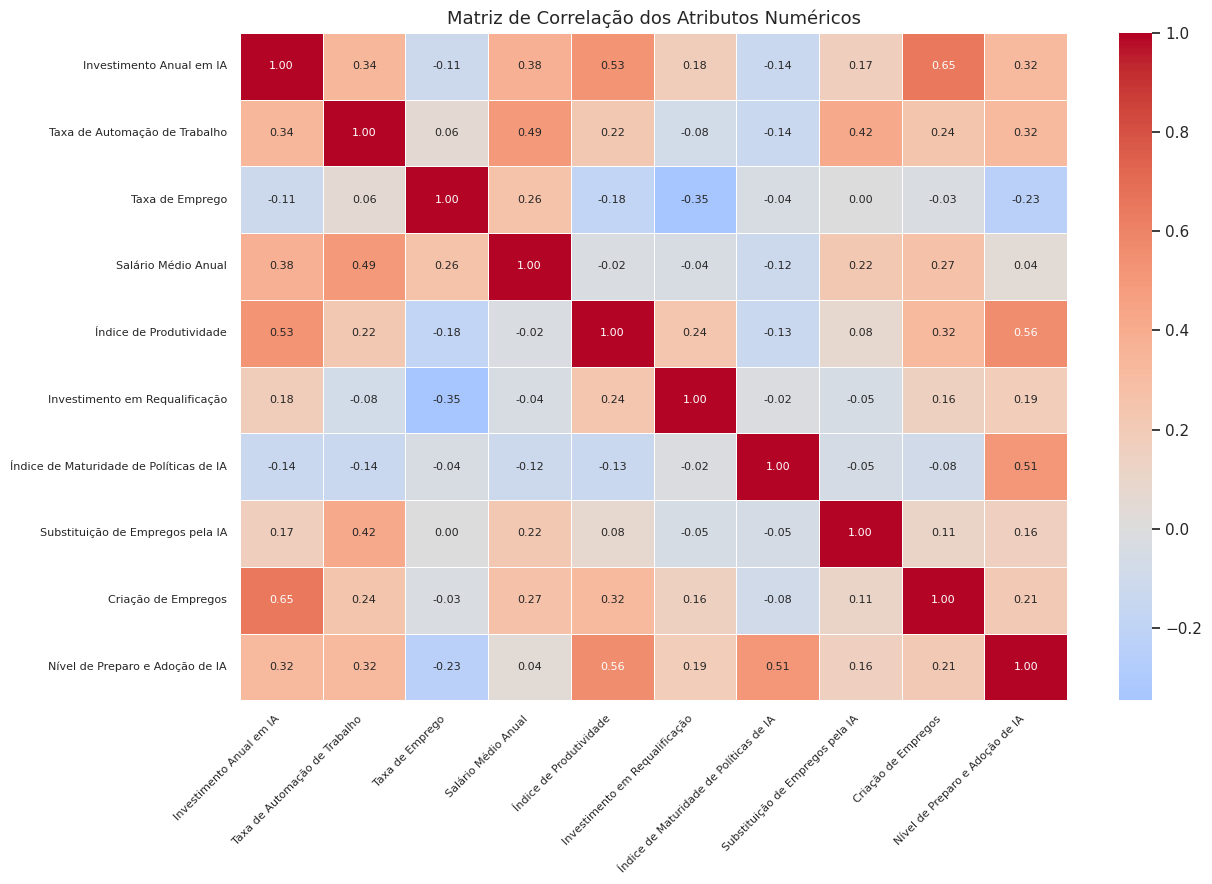

In [ ]:
# Matriz de correlação entre atributos numéricos excluindo Year
corr_matrix = df[numeric_cols].corr()

# Mapeamento dos nomes das colunas para português no heatmap
corr_matrix.columns = [labels[col] for col in corr_matrix.columns]
corr_matrix.index = [labels[col] for col in corr_matrix.index]

plt.figure(figsize=(13, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Matriz de Correlação dos Atributos Numéricos', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Como o dataset acompanha os mesmos países ao longo de vários anos, cada linha representa uma observação do tipo país-ano, e não um caso totalmente independente dos demais. Assim, parte das associações identificadas pode refletir características persistentes de cada país e tendências temporais do período analisado, o que exige cautela na interpretação das correlações.

**H1: Países que investem mais em IA apresentam maior taxa de automação?**

**Variáveis:**
- `Investimento Anual em IA` x `Taxa de Automação de Trabalho`
  - **Correlação: 0,34**
    - Correlação positiva fraca.

**Conclusão preliminar:**
- A hipótese 1 recebe apoio parcial no heatmap. Países com maior investimento em IA tendem a apresentar maior taxa de automação, porém a associação é apenas fraca.

---
**H2: Países que investem mais em IA geram mais empregos?**

**Variáveis:**
- `Investimento Anual em IA` x `Criação de Empregos`
  - **Correlação: 0,65**
    - Correlação positiva moderadamente forte.

**Conclusão preliminar:**
- A hipótese 2 recebe apoio considerável no heatmap. Há associação positiva relevante entre investimento em IA e criação de empregos.

---
**H3: Países com maior nível de preparo e adoção de IA investem proporcionalmente mais na requalificação profissional?**

**Variáveis:**
- `Nível de Preparo e Adoção de IA` e `Investimento em Requalificação`
  - **Correlação: 0,19**
    - Correlação positiva muito fraca.

**Conclusão preliminar:**
- A hipótese 3 recebe pouco apoio no heatmap. A associação entre preparo para IA e investimento em requalificação é positiva, mas muito fraca, praticamente não há evidência forte de associação linear.

---
**H4: A produtividade está associada ao nível de preparo do país, às políticas de IA e/ou ao volume de investimento em IA?**

**Variáveis:**
- `Índice de Produtividade` x `Nível de Preparo e Adoção de IA`
  - **Correlação: 0,56**
    - Correlação positiva moderada.

- `Índice de Produtividade` x `Índice de Maturidade de Políticas de IA`
  - **Correlação: -0,13**
    - Correlação negativa fraca.

- `Índice de Produtividade` x `Investimento Anual em IA`
  - **Correlação: 0,53**
    - Correlação positiva moderada.


**Conclusão preliminar:**
- A hipótese 4 recebe apoio parcial. A produtividade mostra associação positiva moderada com o nível de preparo do país e com o investimento em IA, mas não apresenta associação relevante com a maturidade das políticas de IA.

---
**H5: Países com políticas de IA mais maduras investem mais na requalificação de seus trabalhadores?**

**Variáveis:**
- `Índice de Maturidade de Políticas de IA` x `Investimento em Requalificação`
  - **Correlação: -0,02**
    - Correlação praticamente nula.

**Conclusão preliminar:** A hipótese 5 não recebe apoio no heatmap. Não há evidência de associação linear relevante entre maturidade das políticas de IA e investimento em requalificação.

---
**H6: O avanço da automação está associado ao aumento do deslocamento de trabalhadores?**

**Variáveis:**
- `Taxa de Automação de Trabalho` x `Substituição de Empregos pela IA`
  - **Correlação: 0,42**
    - Correlação positiva moderada.

**Conclusão preliminar:**:
- A hipótese 6 recebe apoio moderado no heatmap. O avanço da automação está moderadamente associado ao aumento da substituição de empregos.

---
**H7: O deslocamento de empregos é compensado pela criação de novos postos ao longo do período analisado?**

**Variáveis:**
- `Substituição de Empregos pela IA` x `Criação de Empregos`
  - **Correlação: 0,11**
    - Correlação positiva muito fraca.

**Conclusão preliminar:**:
-  A hipótese 7 recebe pouco apoio no heatmap. A correlação entre substituição e criação de empregos é muito fraca, o que não sugere compensação clara apenas na associação linear.


# Pré-Processamento de Dados

Preparo dos dados para análises futuras e eventuais etapas de modelagem. Com base nos achados da análise exploratória, as seguintes operações foram identificadas como necessárias ou relevantes:

1. **Tratamento de valores faltantes**: Verifica valores faltantes.
2. **Correção de escala do `AI_Policy_Index`**: Único atributo em escala 0–1, enquanto os demais índices operam em escalas distintas.
3. **Normalização**: Escalonamento de todos os atributos numéricos para o intervalo 0–1 (MinMaxScaler).
4. **Padronização**: Transformação para média 0 e desvio padrão 1 (StandardScaler).
5. **One-Hot Encoding**: Codificação da variável categórica `Country`.

Cada operação é salva em um DataFrame separado, preservando o dataset original intacto. Os outliers de `Job_Creation_Million` foram mantidos por representarem eventos reais e legítimos de alta criação de empregos e não erros de medição.

## 1.Tratamento de Valores Faltantes

Verificação e tratamento de valores faltantes. Embora a ausência de nulos já tenha sido identificada na etapa de análise exploratória, a confirmação é realizada aqui formalmente.

In [ ]:
# Confirmação formal de ausência de valores faltantes
print("Valores faltantes por coluna:")
print(df.isnull().sum())
print(f"\nTotal de valores faltantes: {df.isnull().sum().sum()}")

Valores faltantes por coluna:
Year                                0
Country                             0
AI_Investment_BillionUSD            0
Automation_Rate_Percent             0
Employment_Rate_Percent             0
Average_Salary_USD                  0
Productivity_Index                  0
Reskilling_Investment_MillionUSD    0
AI_Policy_Index                     0
Job_Displacement_Million            0
Job_Creation_Million                0
AI_Readiness_Score                  0
dtype: int64

Total de valores faltantes: 0


O dataset não apresenta valores faltantes em nenhuma coluna, dispensando qualquer operação de imputação ou remoção de registros.

## 2. Correção de Escala do AI_Policy_Index

O atributo `AI_Policy_Index` está em escala 0–1, enquanto os demais índices do dataset (`Productivity_Index`, `AI_Readiness_Score`) operam na escala 0–100. Para equiparar as escalas e facilitar comparações, o atributo é multiplicado por 100, passando a representar valores entre 0 e 100.

In [ ]:
# Cópia do dataset original para preservar os dados brutos
df_processado = df.copy()

# Correção de escala do AI_Policy_Index
df_processado['AI_Policy_Index'] = df_processado['AI_Policy_Index'] * 100

print("Escala do AI_Policy_Index após correção:")
print(f"  Mínimo: {df_processado['AI_Policy_Index'].min():.2f}")
print(f"  Máximo: {df_processado['AI_Policy_Index'].max():.2f}")

Escala do AI_Policy_Index após correção:
  Mínimo: 18.00
  Máximo: 100.00


---

In [ ]:
# Colunas numéricas a serem transformadas
cols_escala = df.select_dtypes(include='number').drop(columns=['Year']).columns

## 3. Normalização

A normalização (MinMaxScaler) escala todos os atributos numéricos para o intervalo 0–1, preservando a distribuição original dos dados. É útil para futuramente utilizar em algoritmos sensíveis à magnitude dos valores.

A normalização é aplicada sobre o dataset original, de forma independente das demais transformações.

In [ ]:
# Aplicar MinMaxScaler independentemente, partindo do dataset original
scaler_norm = MinMaxScaler()
df_normalizado = df.copy()
df_normalizado[cols_escala] = scaler_norm.fit_transform(df[cols_escala])

print("Primeiras 5 linhas do dataset normalizado:")
df_normalizado[cols_escala].head()

Primeiras 5 linhas do dataset normalizado:


,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
0,0.273780,0.014652,0.367061,0.128163,0.541613,0.254579,0.560976,0.171717,0.022358,0.571210
1,0.321368,0.037938,0.356110,0.138976,0.568075,0.302263,0.695122,0.141414,0.166667,0.417717
2,0.353191,0.059393,0.342094,0.154443,0.599872,0.349951,0.402439,0.151515,0.243902,0.161130
3,0.390075,0.082679,0.338152,0.189813,0.654930,0.397635,0.621951,0.252525,0.148374,0.357770
4,0.428821,0.116693,0.325449,0.187278,0.629321,0.445324,0.475610,0.232323,0.166667,0.421535


Após a normalização, todos os atributos numéricos estão na escala 0-1. A distribuição relativa dos dados é preservada, apenas a magnitude é alterada. Isso elimina o efeito de atributos com escalas muito maiores dominarem análises futuras.

## 4. Padronização

A padronização (StandardScaler) transforma os atributos para média 0 e desvio padrão 1.


In [ ]:
# Aplicar StandardScaler independentemente, partindo do dataset original
scaler_std = StandardScaler()
df_padronizado = df.copy()
df_padronizado[cols_escala] = scaler_std.fit_transform(df[cols_escala])

print("Primeiras 5 linhas do dataset padronizado:")
df_padronizado[cols_escala].head()

Primeiras 5 linhas do dataset padronizado:


,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
0,-0.704864,-1.878090,-0.570191,-1.218966,0.466677,-0.442694,0.216795,-0.796904,-1.089550,0.708850
1,-0.512057,-1.777410,-0.613141,-1.168569,0.578705,-0.238820,0.888553,-0.933021,-0.391230,-0.012986
2,-0.383126,-1.684649,-0.668118,-1.096479,0.713319,-0.034927,-0.577102,-0.887648,-0.017480,-1.219635
3,-0.233688,-1.583969,-0.683580,-0.931632,0.946409,0.168947,0.522140,-0.433925,-0.479749,-0.294896
4,-0.076708,-1.436909,-0.733402,-0.943446,0.837995,0.372840,-0.210688,-0.524669,-0.391230,0.004971


A padronização é preferível porque, diferentemente da normalização, não confina os dados num intervalo fixo [0, 1], evitando que os outliers comprimam a distribuição dos demais valores. Os outliers continuam presentes, mas não distorcem a escala dos pontos não-outliers de forma tão acentuada.

## 5. One-Hot Encoding

O One-Hot Encoding transforma a variável categórica `Country` em 20 colunas binárias — uma por país. Cada coluna recebe valor 1 quando o registro corresponde àquele país e 0 caso contrário. Essa transformação é necessária para algoritmos de machine learning que não aceitam variáveis categóricas diretamente.

In [ ]:
# Aplicar One-Hot Encoding na coluna Country
df_encoded = pd.get_dummies(df.copy(), columns=['Country'], prefix='pais')

print(f"Dimensões antes do encoding: {df.shape}")
print(f"Dimensões após o encoding:   {df_encoded.shape}")
print(f"\nNovas colunas criadas:")
print([col for col in df_encoded.columns if col.startswith('pais_')])

Dimensões antes do encoding: (220, 12)
Dimensões após o encoding:   (220, 31)

Novas colunas criadas:
['pais_Australia', 'pais_Brazil', 'pais_Canada', 'pais_China', 'pais_France', 'pais_Germany', 'pais_India', 'pais_Italy', 'pais_Japan', 'pais_Mexico', 'pais_Netherlands', 'pais_Russia', 'pais_Singapore', 'pais_South Africa', 'pais_South Korea', 'pais_Spain', 'pais_Sweden', 'pais_Turkey', 'pais_United Kingdom', 'pais_United States']


O One-Hot Encoding expandiu o dataset de 12 para 31 colunas. A coluna `Country`
foi substituída por 20 colunas binárias (uma por país), resultando em 12 - 1 + 20 = 31 colunas. Cada registro agora pode ser interpretado por algoritmos de machine learning sem a necessidade de tratar texto.

# Respondendo às Hipóteses

Esta seção investiga cada hipótese levantada na definição do problema, utilizando visualizações específicas e os dados explorados ao longo da análise.

## H1: Países que investem mais em IA apresentam maior taxa de automação?

**Variáveis:** `AI_Investment_BillionUSD` × `Automation_Rate_Percent`

**Correlação identificada no heatmap:** r = 0,34 (positiva fraca)

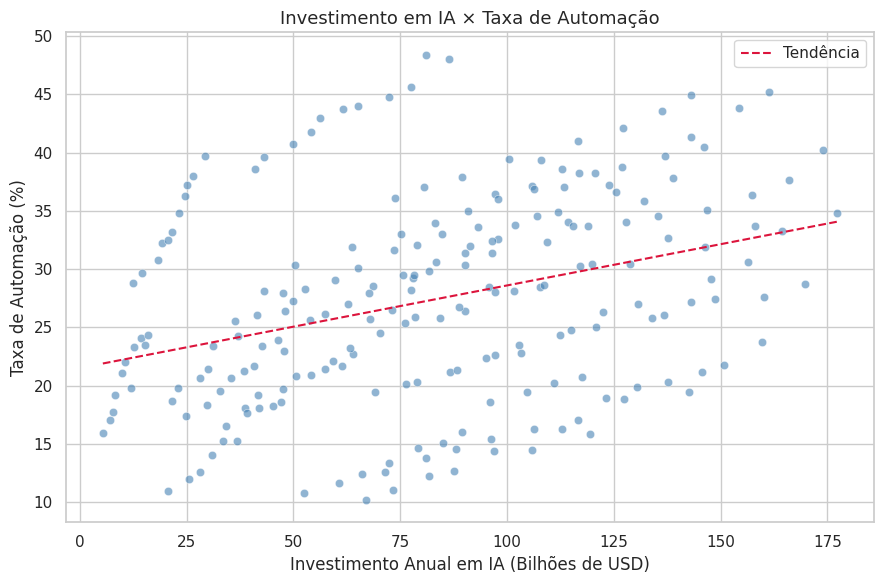

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='AI_Investment_BillionUSD',
    y='Automation_Rate_Percent',
    alpha=0.6,
    color='steelblue'
)

# Linha de tendência
m, b = np.polyfit(df['AI_Investment_BillionUSD'], df['Automation_Rate_Percent'], 1)
x_line = np.linspace(df['AI_Investment_BillionUSD'].min(),
                     df['AI_Investment_BillionUSD'].max(), 100)
plt.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5,
         linestyle='--', label='Tendência')

plt.title('Investimento em IA × Taxa de Automação', fontsize=13)
plt.xlabel('Investimento Anual em IA (Bilhões de USD)')
plt.ylabel('Taxa de Automação (%)')
plt.legend()
plt.tight_layout()
plt.show()

O scatter plot confirma a correlação positiva fraca (r = 0,34) identificada na matriz de correlação. A linha de tendência indica que países com maior investimento em IA tendem a apresentar taxas de automação mais altas, mas a dispersão dos pontos é grande. Muitos países com investimentos similares apresentam taxas de automação bastante diferentes.

**Resposta à H1:** A hipótese recebe apoio parcial. Há uma tendência positiva entre investimento em IA e taxa de automação, mas a associação é fraca, indicando que outros fatores além do investimento influenciam o nível de automação dos países.

## H2: Países que investem mais em IA geram mais empregos?

**Variáveis:** `AI_Investment_BillionUSD` × `Job_Creation_Million`

**Correlação identificada no heatmap:** r = 0,65 (positiva moderadamente forte)

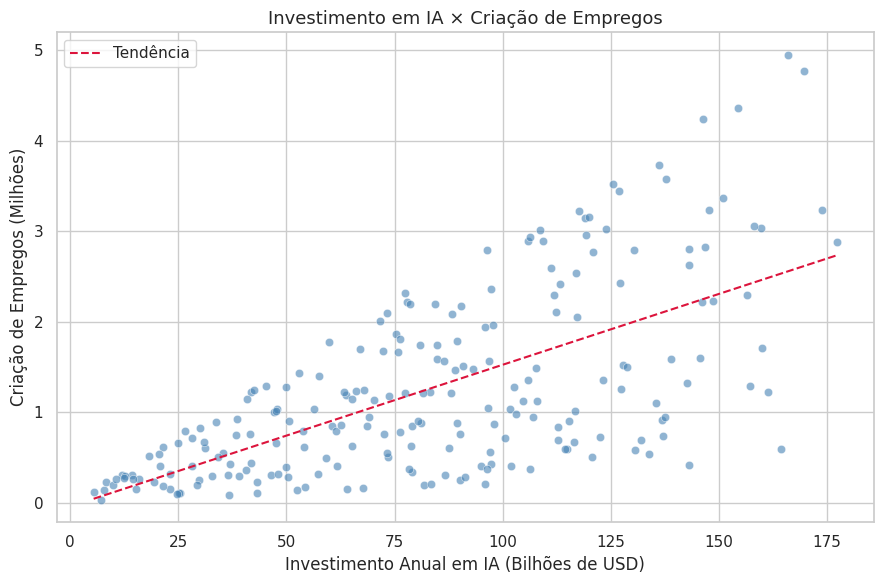

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='AI_Investment_BillionUSD',
    y='Job_Creation_Million',
    alpha=0.6,
    color='steelblue'
)

# Linha de tendência
m, b = np.polyfit(df['AI_Investment_BillionUSD'], df['Job_Creation_Million'], 1)
x_line = np.linspace(df['AI_Investment_BillionUSD'].min(),
                     df['AI_Investment_BillionUSD'].max(), 100)
plt.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5,
         linestyle='--', label='Tendência')

plt.title('Investimento em IA × Criação de Empregos', fontsize=13)
plt.xlabel('Investimento Anual em IA (Bilhões de USD)')
plt.ylabel('Criação de Empregos (Milhões)')
plt.legend()
plt.tight_layout()
plt.show()

O scatter plot confirma a correlação positiva moderadamente forte (r = 0,65)
identificada na matriz de correlação, a mais forte do dataset. A linha de tendência é clara e os pontos se distribuem de forma mais concentrada ao redor dela do que na H1, indicando uma associação mais consistente entre as variáveis.

Os 5 outliers de `Criação de Empregos` são visíveis na parte superior do gráfico, correspondendo aos casos de alta criação de empregos já identificados anteriormente. Mesmo com sua presença, a tendência positiva se mantém.

**Resposta à H2:** A hipótese recebe apoio considerável, sugerindo que países com maior investimento em IA geram mais postos de trabalho, com associação positiva moderadamente forte.

## H3: Países com maior nível de preparo e adoção de IA investem proporcionalmente mais na requalificação profissional?

**Variáveis:** `AI_Readiness_Score` × `Reskilling_Investment_MillionUSD`

**Correlação identificada no heatmap:** r = 0,19 (positiva muito fraca)

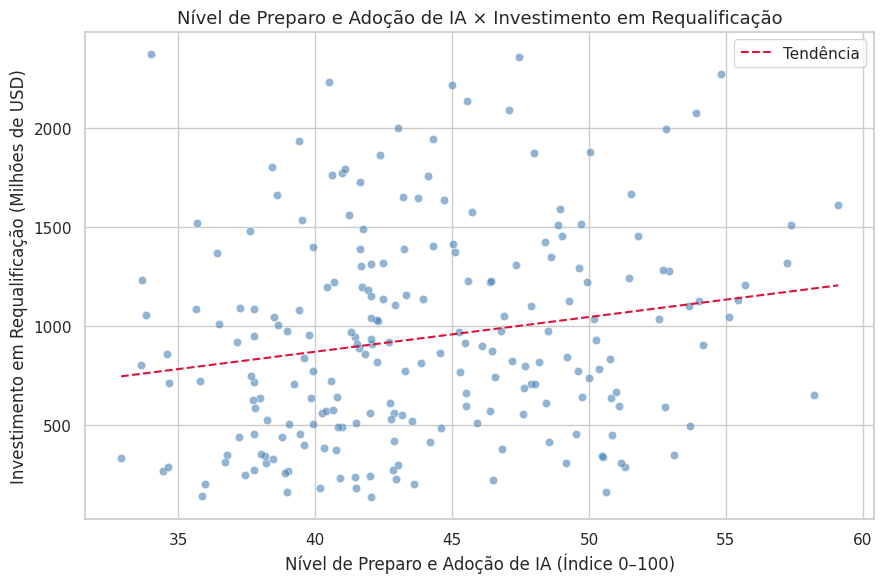

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='AI_Readiness_Score',
    y='Reskilling_Investment_MillionUSD',
    alpha=0.6,
    color='steelblue'
)

# Linha de tendência
m, b = np.polyfit(df['AI_Readiness_Score'],
                  df['Reskilling_Investment_MillionUSD'], 1)
x_line = np.linspace(df['AI_Readiness_Score'].min(),
                     df['AI_Readiness_Score'].max(), 100)
plt.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5,
         linestyle='--', label='Tendência')

plt.title('Nível de Preparo e Adoção de IA × Investimento em Requalificação',
          fontsize=13)
plt.xlabel('Nível de Preparo e Adoção de IA (Índice 0–100)')
plt.ylabel('Investimento em Requalificação (Milhões de USD)')
plt.legend()
plt.tight_layout()
plt.show()

O scatter plot confirma a correlação positiva muito fraca (r = 0,19) identificada na matriz de correlação. A dispersão dos pontos é ampla e a linha de tendência é praticamente plana, indicando ausência de associação linear relevante entre o nível de preparo para IA e o investimento em requalificação profissional.

**Resposta à H3:** A hipótese não recebe apoio nos dados. Países com maior nível de preparo e adoção de IA não necessariamente investem mais em requalificação profissional, sugerindo que esses dois aspectos evoluem de forma independente entre os países analisados.

## H4: A produtividade de um país está associada ao nível de preparo e adoção de IA, à maturidade das políticas de IA e/ou ao volume de investimento em IA?

**Variáveis:** `Productivity_Index` × `AI_Readiness_Score`, `AI_Policy_Index` e `AI_Investment_BillionUSD`

**Correlações identificadas no heatmap:**
- `Productivity_Index` × `AI_Readiness_Score`: r = 0,56 (positiva moderada)
- `Productivity_Index` × `AI_Policy_Index`: r = -0,13 (negativa fraca)
- `Productivity_Index` × `AI_Investment_BillionUSD`: r = 0,53 (positiva moderada)


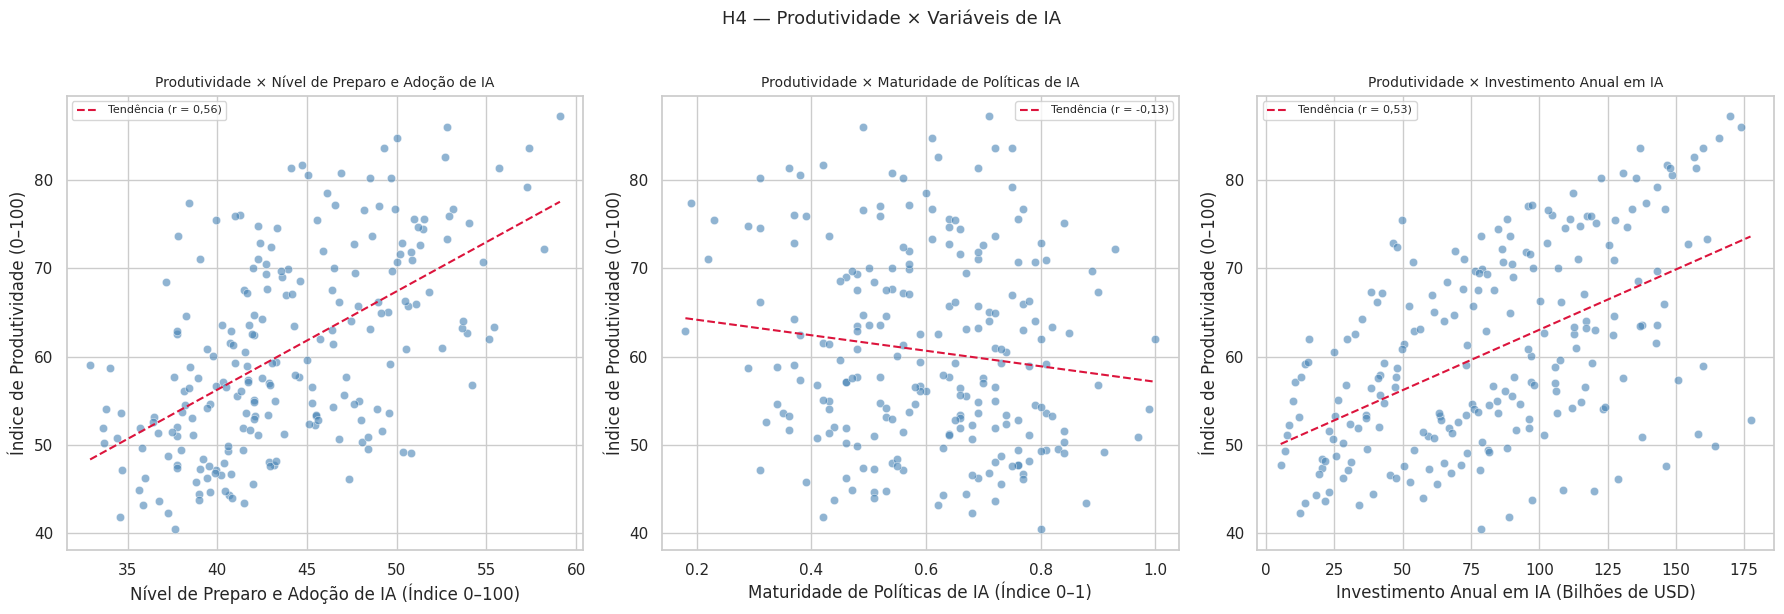

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

variaveis = [
    ('AI_Readiness_Score',       'Nível de Preparo e Adoção de IA (Índice 0–100)', 'r = 0,56'),
    ('AI_Policy_Index',          'Maturidade de Políticas de IA (Índice 0–1)',      'r = -0,13'),
    ('AI_Investment_BillionUSD', 'Investimento Anual em IA (Bilhões de USD)',       'r = 0,53'),
]

for ax, (col, xlabel, corr_label) in zip(axes, variaveis):
    sns.scatterplot(data=df, x=col, y='Productivity_Index',
                    alpha=0.6, color='steelblue', ax=ax)

    m, b = np.polyfit(df[col], df['Productivity_Index'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson',
            linewidth=1.5, linestyle='--', label=f'Tendência ({corr_label})')

    ax.set_title(f'Produtividade × {xlabel.split("(")[0].strip()}', fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Índice de Produtividade (0–100)')
    ax.legend(fontsize=8)

plt.suptitle('H4 — Produtividade × Variáveis de IA', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Os três scatter plots revelam padrões distintos:

- **Produtividade × Nível de Preparo e Adoção de IA** (r = 0,56): associação positiva moderada. Países com maior nível de preparo para IA tendem a ser mais produtivos.
A linha de tendência é clara e os pontos apresentam dispersão moderada.

- **Produtividade × Maturidade de Políticas de IA** (r = -0,13): ausência de
associação relevante. A linha de tendência é praticamente plana e ligeiramente
negativa, indicando que a maturidade das políticas de IA isoladamente não está
associada à produtividade.

- **Produtividade × Investimento em IA** (r = 0,53): associação positiva moderada similar à anterior. Países que investem mais em IA tendem a ser mais produtivos.

**Resposta à H4:** A hipótese recebe apoio parcial. A produtividade está associada moderadamente ao nível de preparo para IA e ao volume de investimento em IA, mas não apresenta associação relevante com a maturidade das políticas de IA.

## H5: Países com políticas de IA mais maduras investem mais na requalificação de seus trabalhadores?

**Variáveis:** `AI_Policy_Index` × `Reskilling_Investment_MillionUSD`

**Correlação identificada no heatmap:** r = -0,02 (praticamente nula)

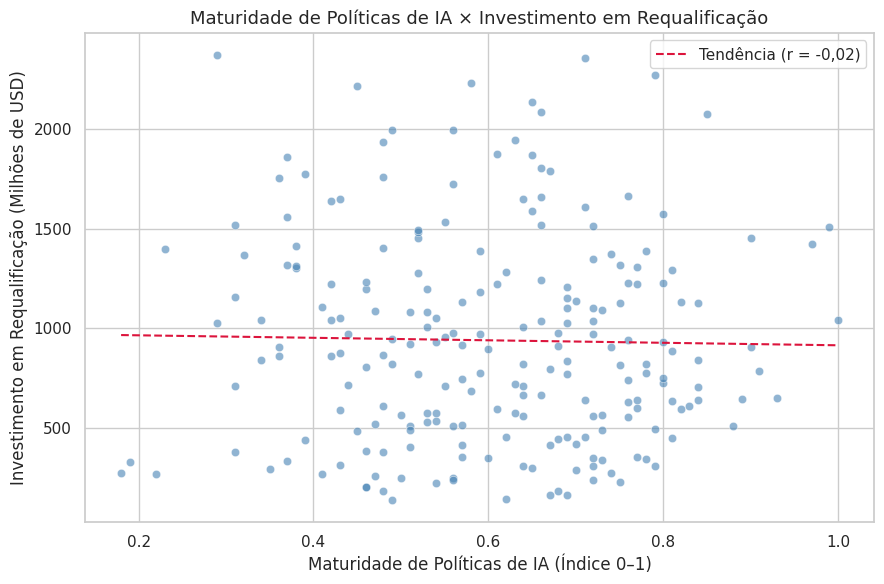

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='AI_Policy_Index',
    y='Reskilling_Investment_MillionUSD',
    alpha=0.6,
    color='steelblue'
)

# Linha de tendência
m, b = np.polyfit(df['AI_Policy_Index'],
                  df['Reskilling_Investment_MillionUSD'], 1)
x_line = np.linspace(df['AI_Policy_Index'].min(),
                     df['AI_Policy_Index'].max(), 100)
plt.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5,
         linestyle='--', label='Tendência (r = -0,02)')

plt.title('Maturidade de Políticas de IA × Investimento em Requalificação',
          fontsize=13)
plt.xlabel('Maturidade de Políticas de IA (Índice 0–1)')
plt.ylabel('Investimento em Requalificação (Milhões de USD)')
plt.legend()
plt.tight_layout()
plt.show()

O scatter plot confirma a correlação praticamente nula (r = -0,02) identificada na matriz de correlação. A linha de tendência é essencialmente plana e os pontos estão distribuídos de forma completamente aleatória ao longo de todo o intervalo do índice de políticas de IA, sem nenhum padrão visual identificável.

**Resposta à H5:** A hipótese não recebe apoio nos dados. Não há evidência de
associação linear entre a maturidade das políticas de IA e o investimento em requalificação profissional. Países com políticas de IA mais maduras não necessariamente investem mais na requalificação de seus trabalhadores.

## H6: O avanço da automação da força de trabalho está associado ao aumento da substituição de empregos pela IA?

**Variáveis:** `Automation_Rate_Percent` × `Job_Displacement_Million`

**Correlação identificada no heatmap:** r = 0,42 (positiva moderada)

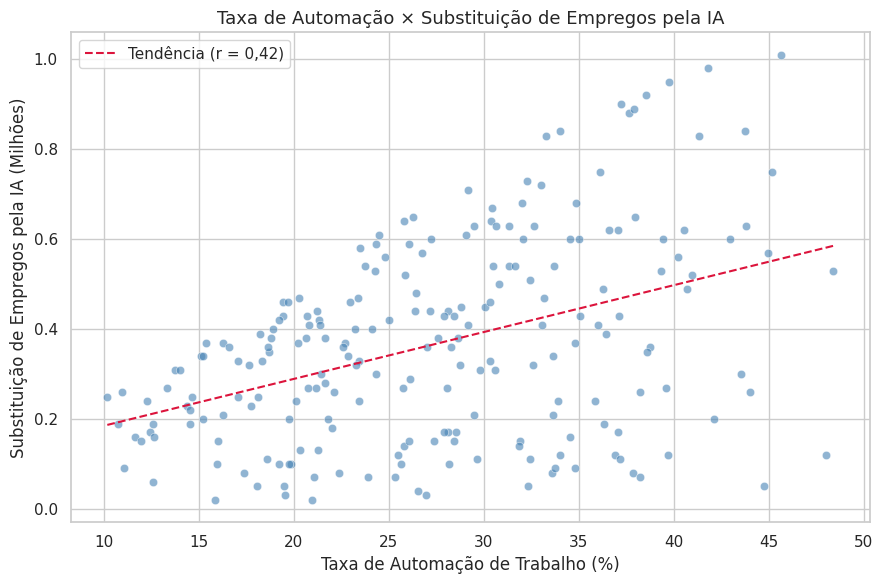

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Automation_Rate_Percent',
    y='Job_Displacement_Million',
    alpha=0.6,
    color='steelblue'
)

# Linha de tendência
m, b = np.polyfit(df['Automation_Rate_Percent'],
                  df['Job_Displacement_Million'], 1)
x_line = np.linspace(df['Automation_Rate_Percent'].min(),
                     df['Automation_Rate_Percent'].max(), 100)
plt.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5,
         linestyle='--', label='Tendência (r = 0,42)')

plt.title('Taxa de Automação × Substituição de Empregos pela IA', fontsize=13)
plt.xlabel('Taxa de Automação de Trabalho (%)')
plt.ylabel('Substituição de Empregos pela IA (Milhões)')
plt.legend()
plt.tight_layout()
plt.show()

O scatter plot confirma a correlação positiva moderada (r = 0,42) identificada na matriz de correlação. A linha de tendência é clara e os pontos apresentam dispersão moderada ao redor dela, indicando que países com maior taxa de automação tendem a registrar maior substituição de empregos pela IA.

**Resposta à H6:** A hipótese recebe apoio moderado nos dados. O avanço da automação da força de trabalho está associado ao aumento da substituição de empregos pela IA, embora a dispersão dos pontos indique que outros fatores também influenciam o deslocamento de trabalhadores.

## H7: A substituição de empregos pela IA é compensada pela criação de novos postos de trabalho ao longo do período analisado?

**Variáveis:** `Job_Displacement_Million` × `Job_Creation_Million`

**Correlação identificada no heatmap:** r = 0,11 (positiva muito fraca)

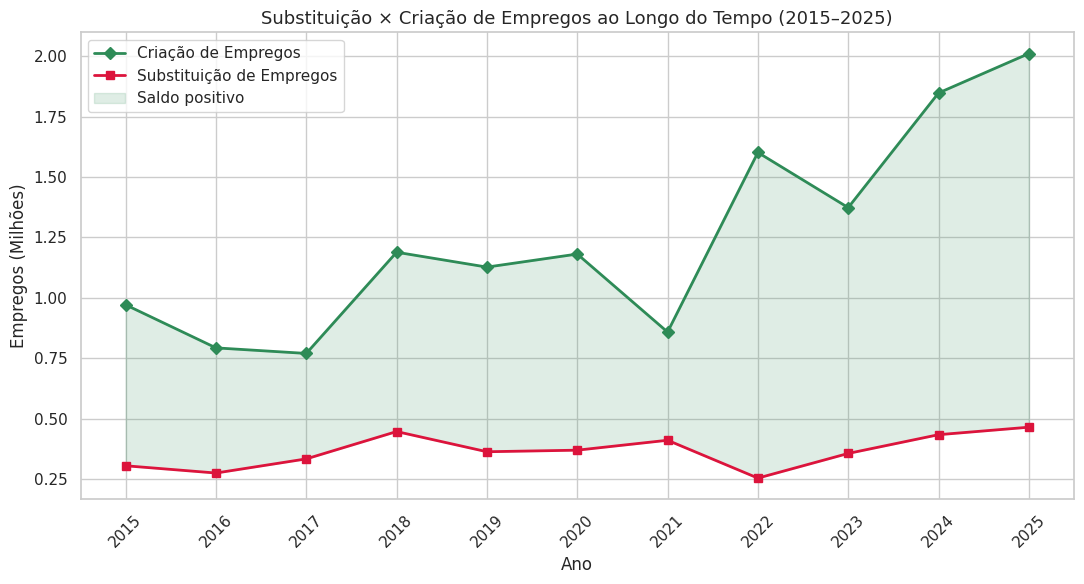

In [ ]:
# Média global por ano de substituição e criação de empregos
evolucao_emprego = df.groupby('Year')[
    ['Job_Displacement_Million', 'Job_Creation_Million']
].mean().reset_index()

plt.figure(figsize=(11, 6))
plt.plot(evolucao_emprego['Year'], evolucao_emprego['Job_Creation_Million'],
         marker='D', color='seagreen', linewidth=2, label='Criação de Empregos')
plt.plot(evolucao_emprego['Year'], evolucao_emprego['Job_Displacement_Million'],
         marker='s', color='crimson', linewidth=2, label='Substituição de Empregos')

plt.fill_between(
    evolucao_emprego['Year'],
    evolucao_emprego['Job_Displacement_Million'],
    evolucao_emprego['Job_Creation_Million'],
    alpha=0.15, color='seagreen', label='Saldo positivo'
)

plt.title('Substituição × Criação de Empregos ao Longo do Tempo (2015–2025)',
          fontsize=13)
plt.xlabel('Ano')
plt.ylabel('Empregos (Milhões)')
plt.xticks(evolucao_emprego['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Distribuição dos registros por relação entre criação e substituição
maior = (df['Job_Creation_Million'] > df['Job_Displacement_Million']).sum()
menor = (df['Job_Creation_Million'] < df['Job_Displacement_Million']).sum()
igual = (df['Job_Creation_Million'] == df['Job_Displacement_Million']).sum()

print(f'Criação > Substituição: {maior} de {len(df)} registros ({maior/len(df)*100:.1f}%)')
print(f'Criação < Substituição: {menor} de {len(df)} registros ({menor/len(df)*100:.1f}%)')
print(f'Criação = Substituição: {igual} de {len(df)} registros ({igual/len(df)*100:.1f}%)')

Criação > Substituição: 178 de 220 registros (80.9%)
Criação < Substituição: 41 de 220 registros (18.6%)
Criação = Substituição: 1 de 220 registros (0.5%)


O gráfico de linhas revela que a criação de empregos supera a substituição em todos os anos analisados, com o saldo positivo se ampliando ao longo do tempo, com queda pontual em 2021 e forte recuperação a partir de 2022. Em 2025, a criação média global atingiu 2,01 milhões de postos, enquanto a substituição foi de 0,47 milhões, uma razão de aproximadamente 4,3 para 1.

Em termos absolutos, 178 dos 220 registros (81%) apresentam criação de empregos
superior à substituição, 41 registros apresentam substituição superior à criação, e 1 registro apresenta valores iguais (Singapura, 2022), reforçando a consistência desse padrão ao longo do período e entre os países analisados.

A correlação fraca entre as duas variáveis (r = 0,11) indica que os dois fenômenos ocorrem de forma independente, o aumento da substituição não implica necessariamente maior criação de empregos. A compensação observada é de natureza quantitativa: a criação supera numericamente a substituição, mas não como resposta direta a ela.

**Resposta à H7:** A hipótese recebe apoio descritivo em termos quantitativos dentro deste dataset. A criação de novos postos supera numericamente a substituição de empregos pela IA em todos os anos analisados, com o saldo favorável à criação se ampliando nos anos mais recentes.

# Limitações do Estudo

Como limitações do estudo, destaca-se que o dataset utilizado é sintético, de modo que os padrões identificados e resultados não devem ser entendidos e interpretados como representação fiel da realidade observada, mas sim, como evidências exploratórias dentro da base analisada.

Além disso, os dados estão organizados por país e ano entre 2015 e 2025, caracterizando observações repetidas dos mesmos países ao longo do tempo. Dessa forma, os achados deste trabalho devem ser entendidos como evidências exploratórias e correlacionais, úteis para identificar padrões e associações no conjunto analisado, sem permitir inferências causais ou generalizações diretas para o mundo real.

# Conclusão

Este trabalho realizou uma análise exploratória do dataset **AI Workforce and Automation Dataset 2015–2025**, cobrindo 20 países ao longo de 11 anos. O objetivo foi investigar, de acordo com o dataset, como o avanço da IA e da automação se relaciona com variáveis de emprego, produtividade e requalificação profissional.

A análise percorreu as etapas de definição do problema, análise exploratória, pré-processamento e resposta às hipóteses levantadas.

A seguir, um resumo dos principais achados:

**Investimento**
- **H1:** Países com maior investimento em IA tendem a apresentar maior taxa de automação, porém a associação é fraca (r = 0,34), indicando que outros fatores influenciam o nível de automação.
- **H2:** O investimento em IA apresenta a associação positiva mais forte do dataset com a criação de empregos (r = 0,65), sugerindo que países que investem mais em IA geram mais postos de trabalho.
- **H3:** Não há evidência de associação relevante entre o nível de preparo para IA e o investimento em requalificação profissional (r = 0,19), indicando que os dois aspectos evoluem de forma independente.

**Produtividade**
- **H4:** A produtividade está moderadamente associada ao nível de preparo para IA (r = 0,56) e ao investimento em IA (r = 0,53), mas não apresenta associação relevante com a maturidade das políticas de IA (r = -0,13).

**Empregabilidade**
- **H5:** Não há associação entre a maturidade das políticas de IA e o investimento em requalificação profissional (r = -0,02), contrariando a hipótese levantada.
- **H6:** O avanço da automação está moderadamente associado ao aumento da substituição de empregos (r = 0,42), confirmando parcialmente a hipótese.
- **H7:** A criação de novos postos supera numericamente a substituição de empregos em todos os anos analisados, com razão de 4,3 para 1 em 2025 e saldo favorável presente em 81% dos registros.

**Considerações finais**

Os resultados sugerem que o investimento em IA é o fator mais diretamente associado tanto à criação de empregos quanto à produtividade, mais do que as políticas públicas de IA isoladamente. A ausência de associação entre políticas de IA e requalificação profissional (H5) e entre preparo para IA e requalificação (H3) indica uma lacuna relevante: países podem estar avançando em adoção de IA sem estruturar adequadamente a preparação de sua força de trabalho.

Como próximos passos, recomenda-se a aplicação de modelos de machine learning para investigar relações causais entre as variáveis, bem como a incorporação de dados socioeconômicos adicionais para enriquecer a análise.